In [1]:
import pandas as pd
import numpy as np

In [2]:
data_protein = pd.read_csv('01_filtro_protein.groups.tsv', sep='\t', index_col=0)

In [3]:

main_columns = ['CBB_01', 'CBB_02', 'CBB_03','rGlyP_07', 'rGlyP_08','rGlyP_09',]
num_columns = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03', 'rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']
all_columns = main_columns + num_columns
cepa_CBB = ['CBB_01', 'CBB_02', 'CBB_03']
cepa_rGlyP = ['rGlyP_07', 'rGlyP_08','rGlyP_09']
cepa_CBB_peptido = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03']
cepa_rGlyP_peptido = ['rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']

In [4]:
 data_protein[cepa_CBB_peptido]

,CBB_UP_01,CBB_UP_02,CBB_UP_03
Protein.Group,,,
O07451,29,34,33
O30338,3,3,3
O87816,12,9,12
P14611,68,66,69
P14697,40,41,41
...,...,...,...
Q83WS0,0,0,0
Q8KLU8,5,5,5
Q9K4U8,1,1,1


In [5]:
data_protein['cepa_CBB_peptido'] = data_protein[cepa_CBB_peptido].sum(axis=1)
data_protein['cepa_rGlyP_peptido'] = data_protein[cepa_rGlyP_peptido].sum(axis=1)

In [6]:
data_protein

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09,CBB_UP_01,CBB_UP_02,CBB_UP_03,rGlyP_UP_07,rGlyP_UP_08,rGlyP_UP_09,cepa_CBB_peptido,cepa_rGlyP_peptido
Protein.Group,,,,,,,,,,,,,,
O07451,26.392931,26.320032,26.349343,NaN,21.201639,NaN,29,34,33,0,4,0,96,4
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205,3,3,3,3,3,3,9,9
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671,12,9,12,12,14,12,33,38
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867,68,66,69,68,69,69,203,206
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088,40,41,41,43,43,43,122,129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q83WS0,NaN,NaN,NaN,33.212505,33.180884,33.246544,0,0,0,84,83,84,0,251
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074,5,5,5,5,6,5,15,16
Q9K4U8,21.286884,21.189563,20.882880,NaN,NaN,21.081498,1,1,1,0,0,1,3,1


In [23]:
data_protein['cepa_rGlyP_peptido'].describe()

count    3422.000000
mean       26.438340
std        33.824203
min         0.000000
25%         6.000000
50%        16.000000
75%        33.000000
max       453.000000
Name: cepa_rGlyP_peptido, dtype: float64

<Axes: >

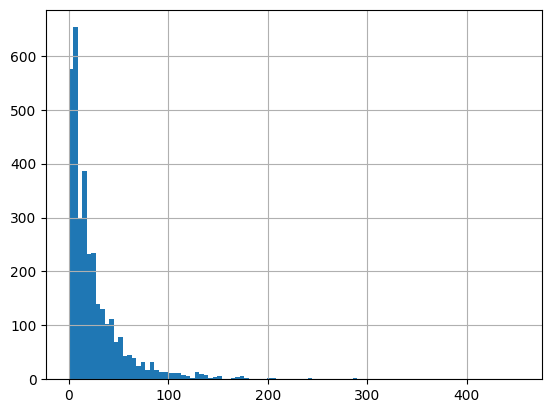

In [ ]:
data_protein['cepa_rGlyP_peptido']

In [41]:
threshold = 4

In [42]:
f"mantuve el {(data_protein[data_protein['cepa_rGlyP_peptido'] >= threshold].shape[0] / data_protein.shape[0]) * 100} % de los datos"

'mantuve el 85.35943892460548 % de los datos'

In [43]:
data_protein_filtro = data_protein[data_protein['cepa_rGlyP_peptido'] >= threshold]

In [44]:
data_protein_filtro

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09,CBB_UP_01,CBB_UP_02,CBB_UP_03,rGlyP_UP_07,rGlyP_UP_08,rGlyP_UP_09,cepa_CBB_peptido,cepa_rGlyP_peptido
Protein.Group,,,,,,,,,,,,,,
O07451,26.392931,26.320032,26.349343,NaN,21.201639,NaN,29,34,33,0,4,0,96,4
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205,3,3,3,3,3,3,9,9
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671,12,9,12,12,14,12,33,38
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867,68,66,69,68,69,69,203,206
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088,40,41,41,43,43,43,122,129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217,8,7,8,7,7,6,23,20
Q83WS0,NaN,NaN,NaN,33.212505,33.180884,33.246544,0,0,0,84,83,84,0,251
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074,5,5,5,5,6,5,15,16


In [45]:
data_protein_filtro[all_columns].to_csv('02_filtro_protein.groups.tsv', sep='\t')